# Linear memory from phenomelogical models

As proposed by Lopez et al. (https://arxiv.org/html/2305.04761v3) or by Favata (https://www.phy.olemiss.edu/StronGBaD/talks/Favata.pdf), the time evolution of the linear memory from the ejecta can be `phenomenologically` modeled using either an exponential or a hyperbolic tangent function. In this notebook, we compare these models and introduce the contribution of the 2 ejecta components (dynamical and wind).

## General function to plot the models

In [25]:
import utils_phenom as up
import importlib

importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI

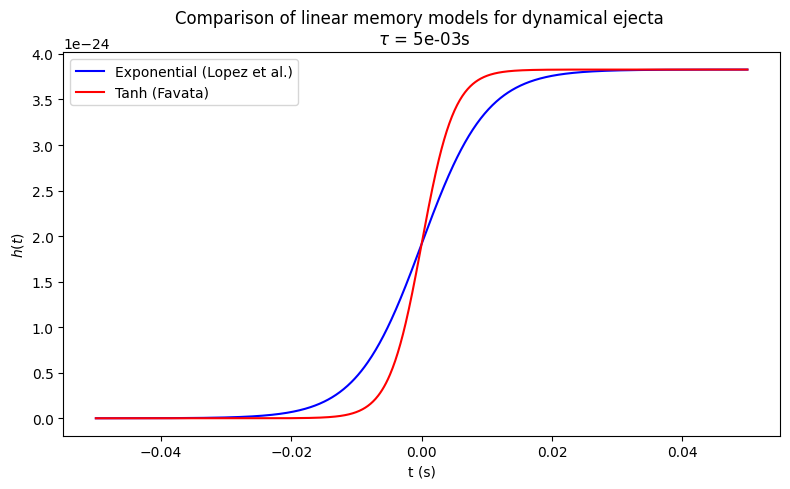

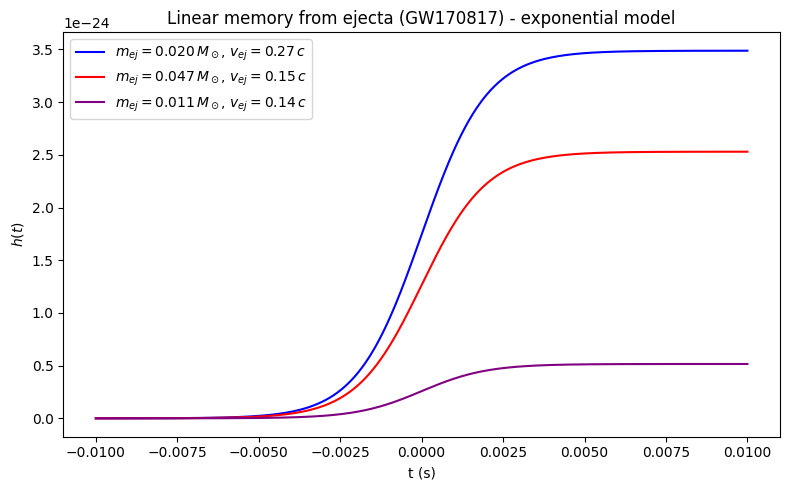

In [26]:
# 1. Plot for typical dynamical ejecta (Lopez vs Favata)
tau = 5e-3  # s
M_ej_dyn = 0.04  # solar masses
v_ej_dyn = 0.2 * C_SI  # m/s
r = 40e6  # parsecs
t = np.linspace(-0.05, 0.05, 1000)

# Exponential model
_, h_lopez = up.phenom_memory_models(tau, M_ej_dyn, v_ej_dyn, r, t, model='exponential', plot=0)
# Tanh model
_, h_favata = up.phenom_memory_models(tau, M_ej_dyn, v_ej_dyn, r, t, model='tanh', plot=0)

plt.figure(figsize=(8, 5))
plt.plot(t, h_lopez, label='Exponential (Lopez et al.)', color='blue')
plt.plot(t, h_favata, label='Tanh (Favata)', color='red')
plt.xlabel("t (s)")
plt.ylabel(r"$h(t)$")
plt.title(f"Comparison of linear memory models for dynamical ejecta \n $\\tau$ = {tau:.0e}s")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot for GW170817 ejecta components (Lopez model)
M_ej_arr = np.array([0.02, 0.047, 0.011])  # solar masses
v_ej_arr = np.array([0.27, 0.15, 0.14]) * C_SI  # m/s
r_gw = 40e6  # parsecs
tau_gw = 0.001  # s
t_gw = np.linspace(-0.01, 0.01, 1000)
colors = ['blue', 'red', 'purple']

plt.figure(figsize=(8, 5))
for i in range(3):
    _, h = up.phenom_memory_models(tau_gw, M_ej_arr[i], v_ej_arr[i], r_gw, t_gw, model='exponential', plot=False)
    plt.plot(t_gw, h, color=colors[i],
             label=f"$m_{{ej}}={M_ej_arr[i]:.3f}\\,M_\\odot$, $v_{{ej}}={v_ej_arr[i]/C_SI:.2f}\\,c$")
plt.xlabel("t (s)")
plt.ylabel(r"$h(t)$")
plt.title("Linear memory from ejecta (GW170817) - exponential model")
plt.legend()
plt.tight_layout()
plt.show()

## Plot of the dynamical, wind and total memory for a given model

To be more physcially motivated, we can apply masks to the memory evolution, so that the memory grows only during the time of activity of each ejecta component. After the end of the activity, the memory remains constant. This is done in the function `linear_memory_ejecta_masked` defined in `utils_phenom.py`. Based on the Table 1 of https://arxiv.org/pdf/1912.05659, the typical time of activity of each ejecta component is given by the following ranges:
- Dynamical ejecta: 0 to 10 ms with a caracteristic timescale of 1 ms
- Wind ejecta: 10 ms to 10 s with a caracteristic timescale of 1 s

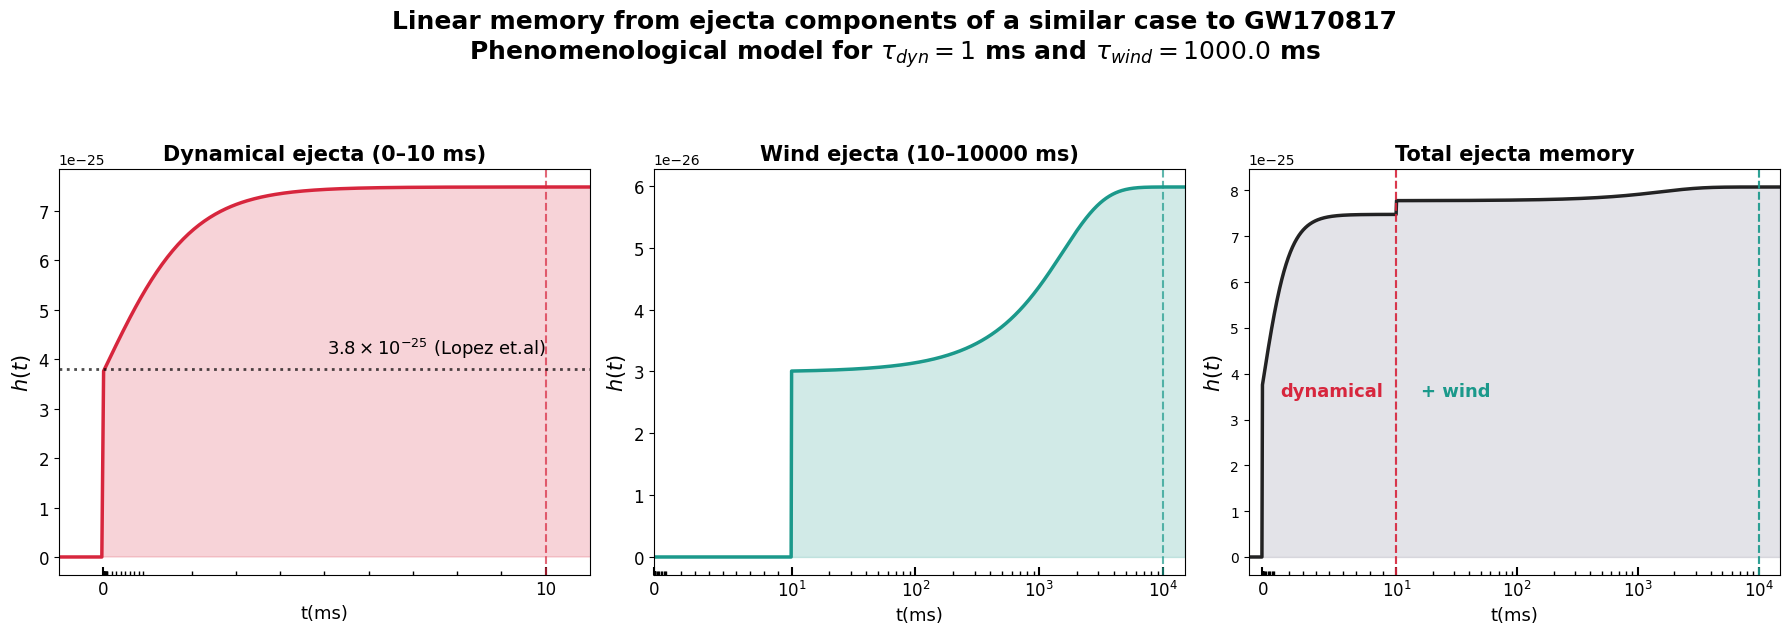

In [27]:
# Parameters 
M_ej_dyn = 0.5*1e-2 * MSUN_SI
v_ej_dyn = 0.25 * C_SI
tau_dyn_ms = 1  

M_ej_wind = 0.01 * MSUN_SI
v_ej_wind = 0.05 * C_SI
tau_wind_ms = 1e3  

r = 40 * PC_SI * 1e6  
t = np.linspace(-5., 15., 500000) * 1e3  # ms

# Physically motivated time ranges for the activity of each ejecta component (to be modified according to the simulations and assumptions: EOS, mass ratio, etc)
start_dyn, end_dyn = 0, 10 
start_wind, end_wind = 10, 10e3 
up.phenom_memory_ejecta_components(
    t, M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    r, model='exponential', plot=True
)

### Comparison of the different caracteristic timescales for each ejecta component

Now we can determined how the caracteristic timescale of each ejecta component impact the total memory evolution :

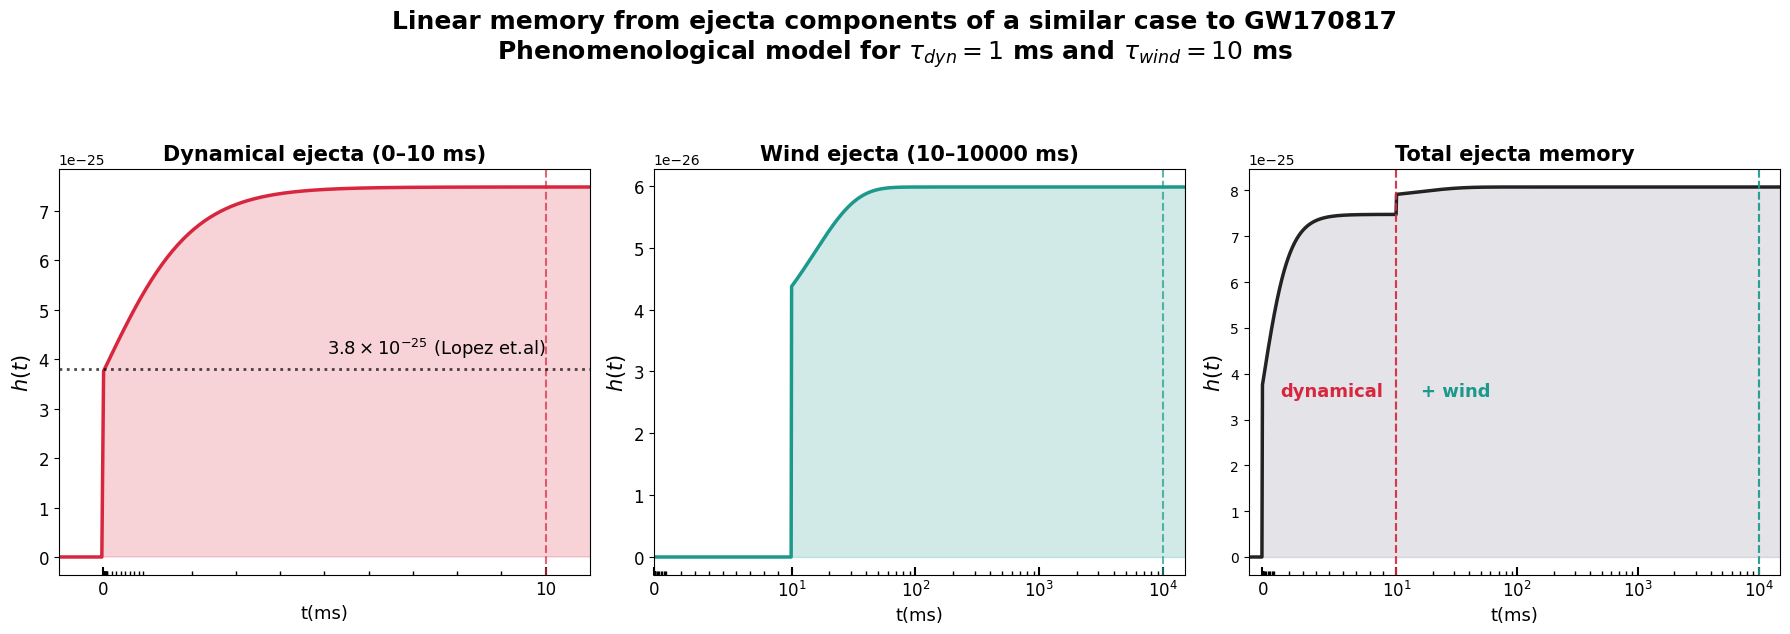

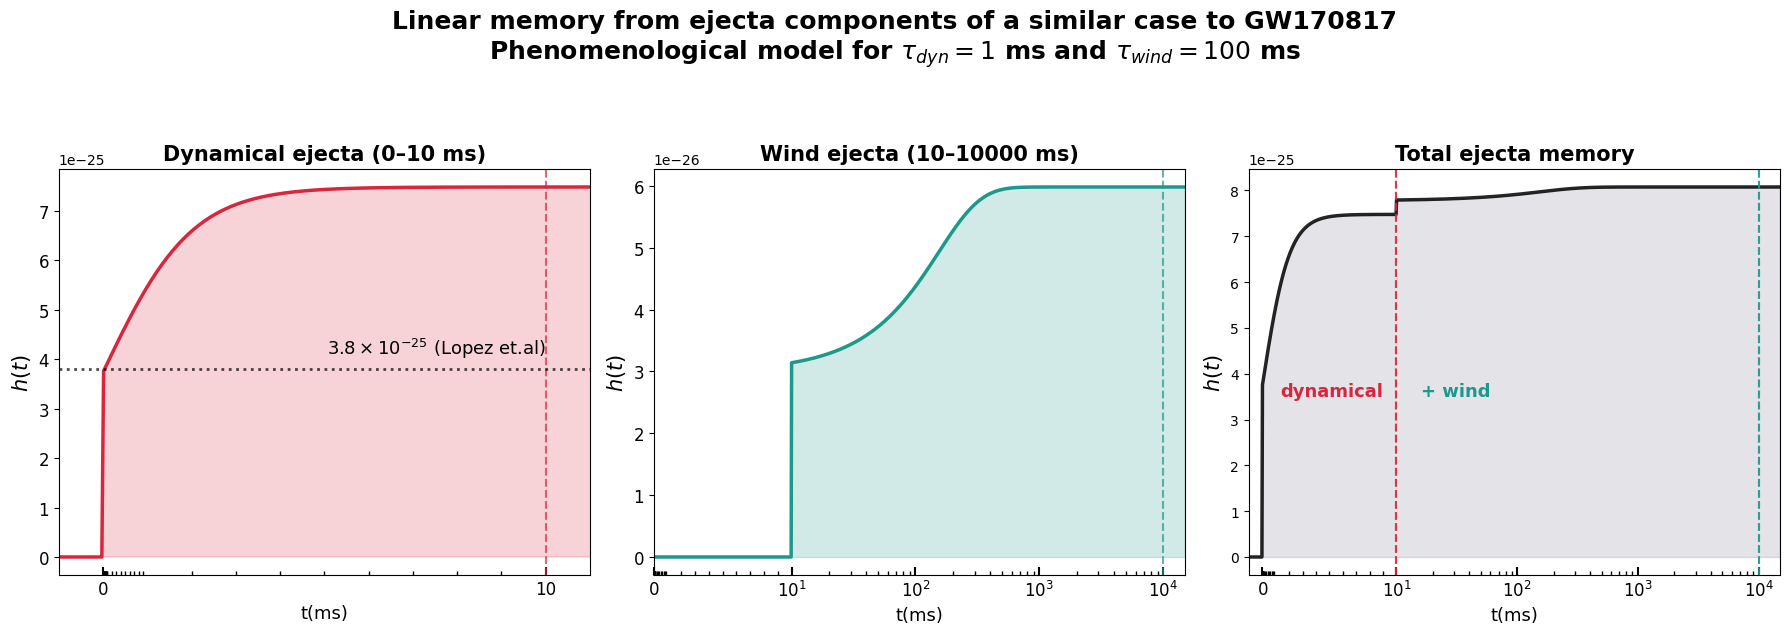

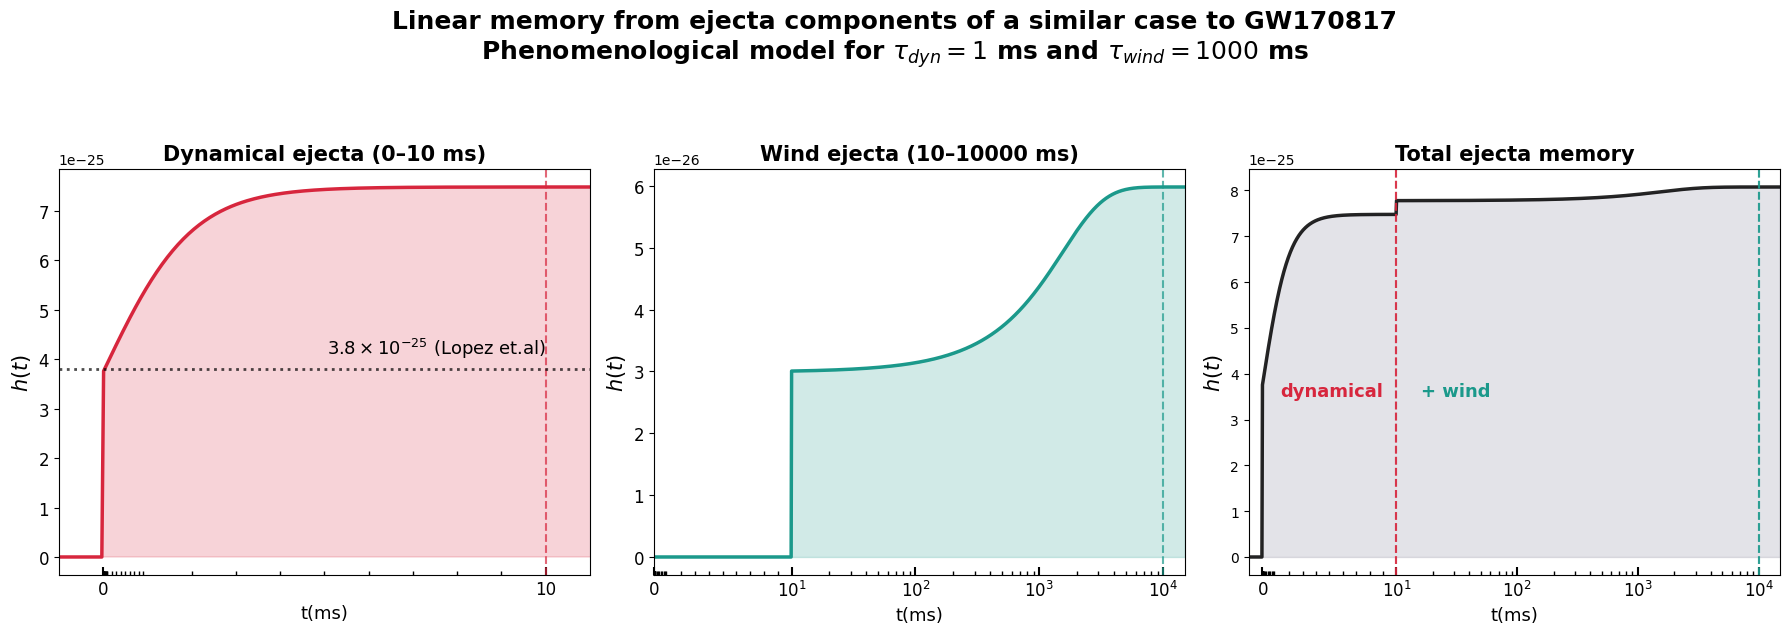

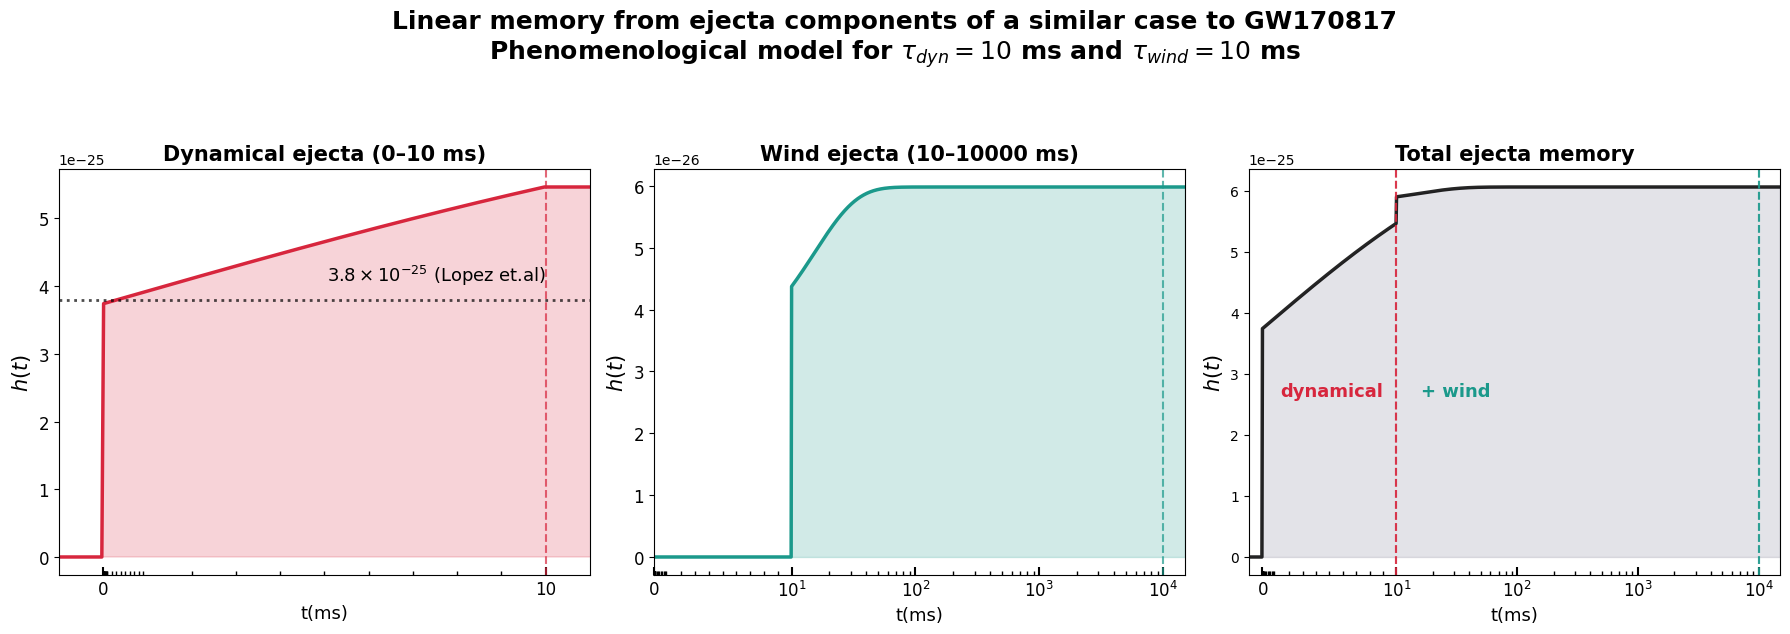

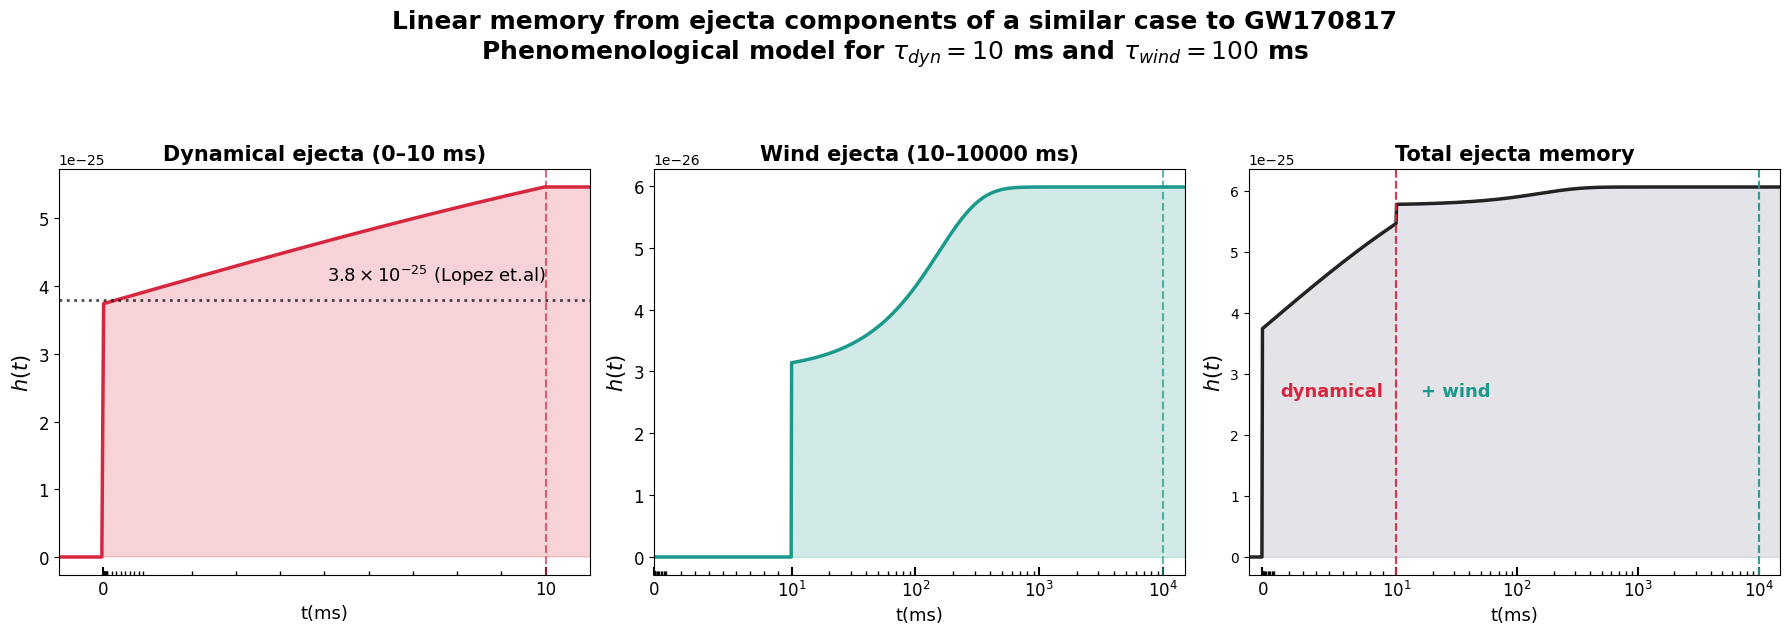

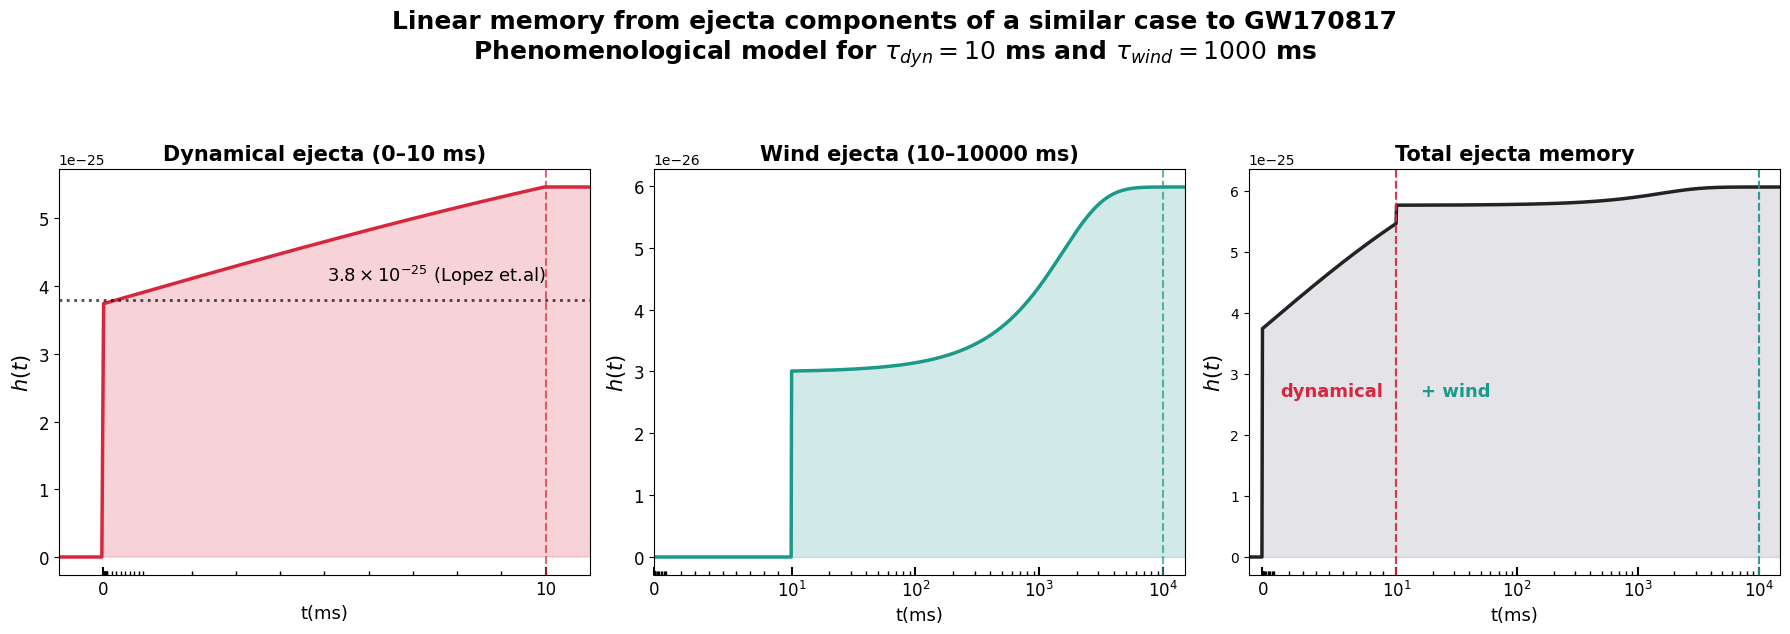

In [28]:
tau_dyn_ms = [1, 10] 
tau_wind_ms = [10,100, 1000] 
for tau_dyn in tau_dyn_ms:
    for tau_wind in tau_wind_ms:
        up.phenom_memory_ejecta_components(
            t, M_ej_dyn, v_ej_dyn, tau_dyn, start_dyn, end_dyn,
            M_ej_wind, v_ej_wind, tau_wind, start_wind, end_wind,
            r, model='exponential', plot=True
        ) 